# Import necessary Libraries

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
celsius    = np.array([-40, -10, 0, 8, 15, 22, 38, 100]).reshape(-1, 1)  # inputs  (data)
fahrenheit = np.array([-40,  14, 32, 46.4, 59, 71.6, 100.4, 212])        # outputs (labels)

In [3]:
model = LinearRegression()  # create a model object
model.fit(celsius, fahrenheit)  # train the model

m = model.coef_[0]  # slope
c = model.intercept_  # intercept

print(f"Slope: {np.round(m, 2)}")
print(f"Intercept: {c}")

print(f"Fahrenheit = {np.round(m, 2)} * Celsius + {c}")

Slope: 1.8
Intercept: 32.0
Fahrenheit = 1.8 * Celsius + 32.0


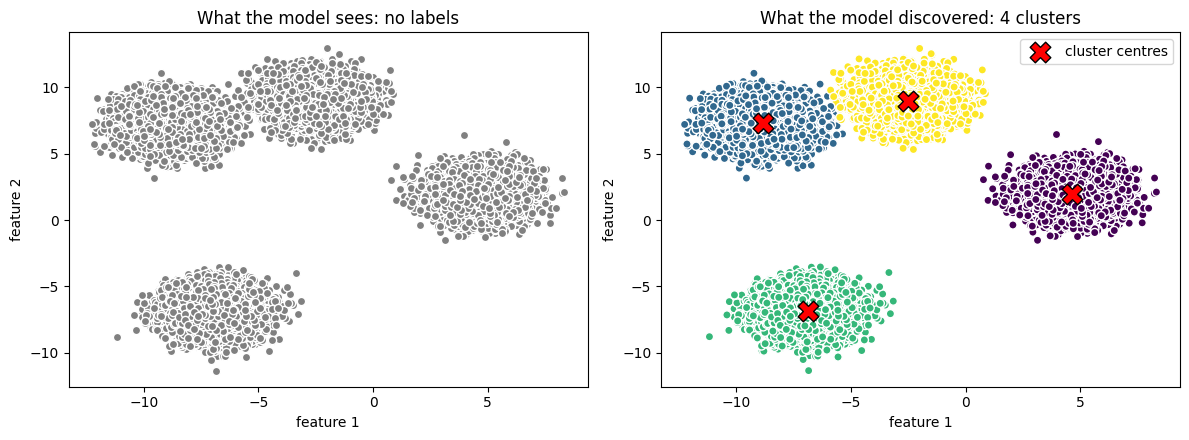

In [6]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

RANDOM_STATE = 42
# Three real groups exist, but the labels are not given to the algorithm.
X, y_true = make_blobs(n_samples=30000, centers=4, cluster_std=1.0, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: what the algorithm receives, an unlabelled cloud of points.
axes[0].scatter(X[:, 0], X[:, 1], c="gray", edgecolor="white", s=35)
axes[0].set_title("What the model sees: no labels")

# Right: KMeans discovers 3 clusters and marks their centres, using only the point positions.
km = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X)
axes[1].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap="viridis", edgecolor="white", s=35)
axes[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                c="red", marker="X", s=220, edgecolor="black", label="cluster centres")
axes[1].set_title("What the model discovered: 4 clusters")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
plt.tight_layout()
plt.show()

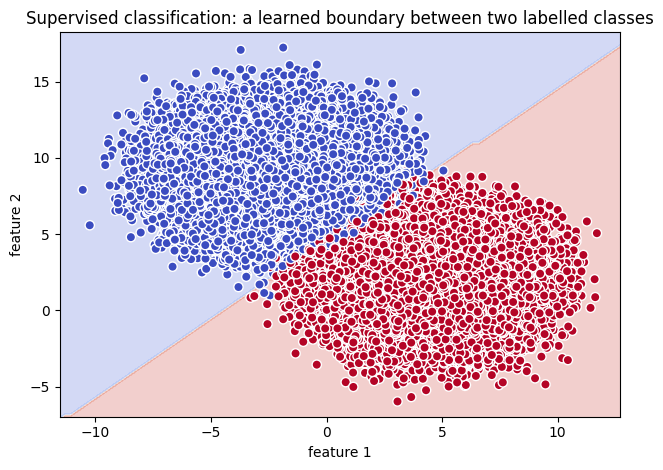

A new point at [0, -6] is predicted to be class: 1


In [5]:
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
# 200 labelled points in two clusters: a binary classification task.
X, y = make_blobs(n_samples=200000, centers=2, cluster_std=1.8, random_state=RANDOM_STATE)

clf = LogisticRegression().fit(X, y)     # learn the boundary from labelled data

fig, ax = plt.subplots()
DecisionBoundaryDisplay.from_estimator(
    clf, X, ax=ax, alpha=0.25, cmap="coolwarm", response_method="predict")
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="white", s=45)
ax.set_title("Supervised classification: a learned boundary between two labelled classes")
ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
plt.tight_layout()
plt.show()

# Predict the class of a new point the model never saw.
new_point = [[0, -6]]
print(f"A new point at {new_point[0]} is predicted to be class: {clf.predict(new_point)[0]}")